In [1]:
#Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Importando a base de dados
df = pd.read_csv("/content/student_habits_performance.csv")

In [4]:
#Visualização dos dados
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


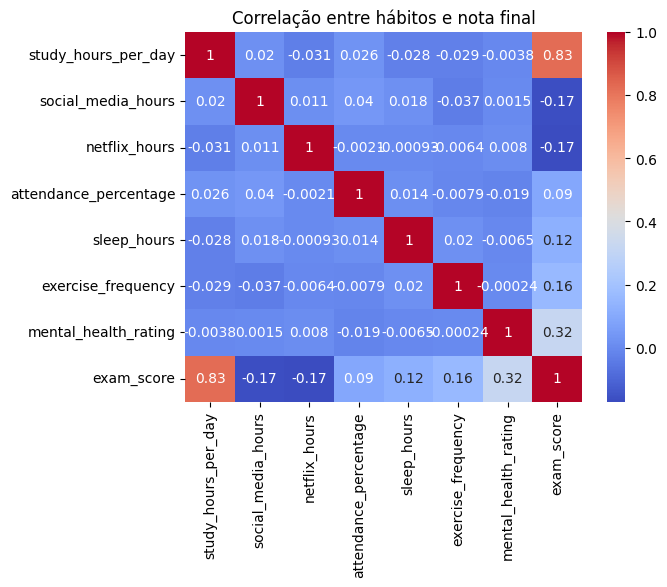

In [6]:
from re import X
#Quais hábitos impactam mais o desempenho dos alunos

#Colunas numéricas para criar um heatmap de colunas com valores numéricos
cols = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

#Heatmap
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre hábitos e nota final")
plt.show()

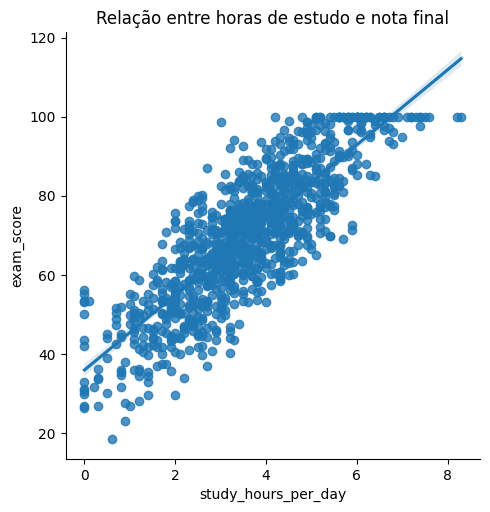

In [7]:
#Alunos que estudam mais, tem mais desempenho?
sns.lmplot(data=df, x="study_hours_per_day", y="exam_score")
plt.title("Relação entre horas de estudo e nota final")
plt.show()

In [8]:
#Comparação horas de estudo: >5h e <2h
filtro_estudo_alto= df["study_hours_per_day"] > 5
filtro_estudo_baixo= df["study_hours_per_day"] < 2

estudo_alto = df[filtro_estudo_alto]["exam_score"]
estudo_baixo = df[filtro_estudo_baixo]["exam_score"]

print("Média de notas (estudo > 5): ", estudo_alto.mean())
print("Média de notas (estudo < 2): ", estudo_baixo.mean())



Média de notas (estudo > 5):  90.79419354838709
Média de notas (estudo < 2):  45.56390977443609


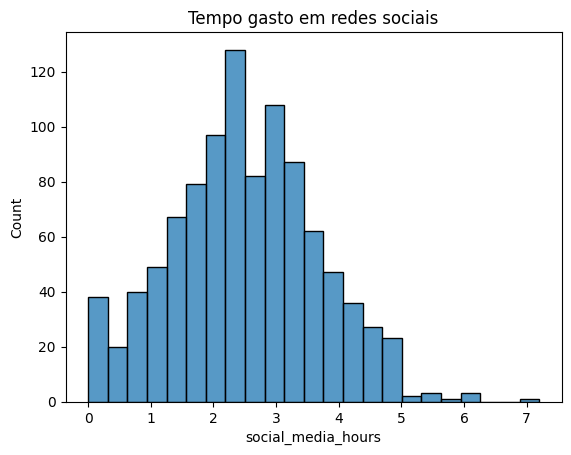

In [9]:
#O tempo gasto em redes dociais afeta o desempenho?

#Histograma redes Sociais
sns.histplot(data=df, x="social_media_hours")
plt.title("Tempo gasto em redes sociais")
plt.show()

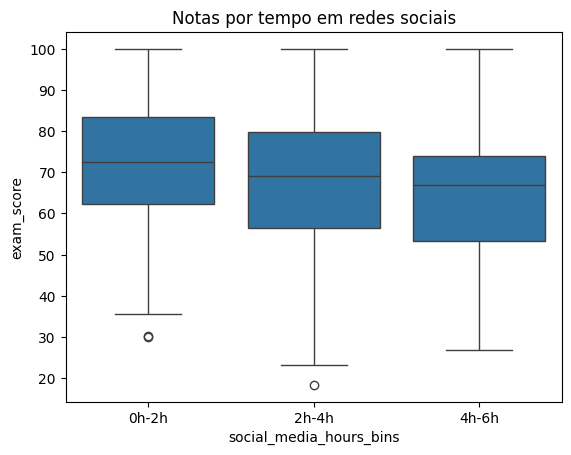

In [15]:
#Avaliando notas médias em diferentes intervalors  (bins)
#[0h, 2h], [2h, 4h], [4h, 6h], [6h+]
df["social_media_hours_bins"] = pd.cut(
    df["social_media_hours"],
    bins=[0, 2, 4, 6],
    labels=["0h-2h", "2h-4h", "4h-6h"]
)

#Gráfico boxplot
sns.boxplot(x="social_media_hours_bins", y="exam_score", data=df)
plt.title("Notas por tempo em redes sociais")
plt.show()

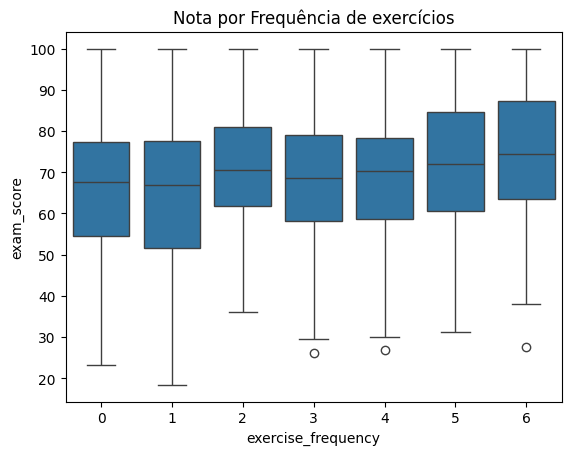

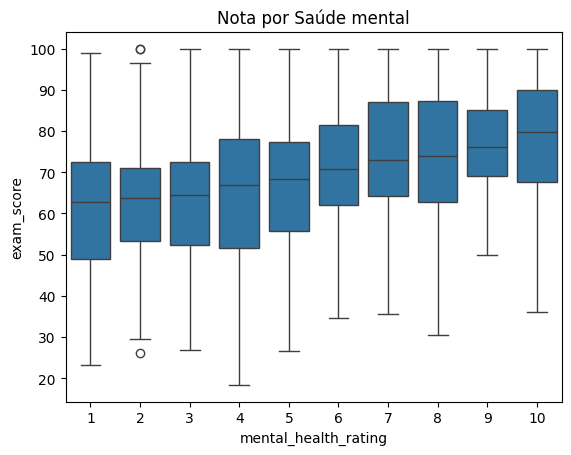

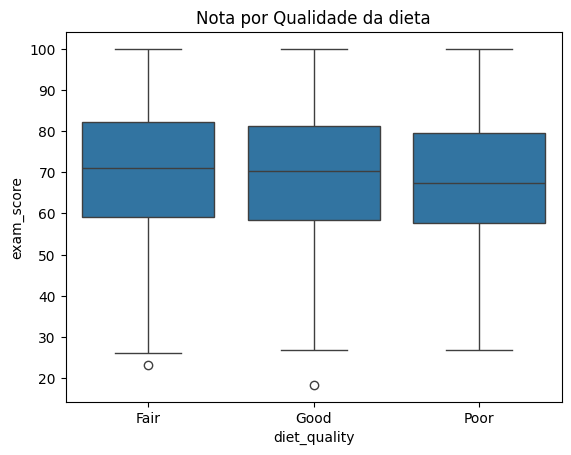

In [23]:
#Frequência de exercícios físicos, saúde mental e boa alimentação aumentam desempenho?
nomes_pt = {
    "exercise_frequency" : "Frequência de exercícios",
    "mental_health_rating" : "Saúde mental",
    "diet_quality" : "Qualidade da dieta"
}

for col in (["exercise_frequency", "mental_health_rating", "diet_quality"]):
  sns.boxplot(x=col, y="exam_score", data=df)
  plt.title(f"Nota por {nomes_pt[col]}")
  plt.show()

In [24]:
#EstatÍsticas por Gênero

df.groupby(["gender"])["exam_score"].mean()

,exam_score
gender,
Female,69.741372
Male,69.368344
Other,70.647619
